# BiPlane Challenge Plots

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import math
import seaborn as sns
import scipy.spatial
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from matplotlib.patches import Rectangle

%config InlineBackend.figure_format='retina'


In [2]:
path = "~/jobs/deploy/decode"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

import decode

In [3]:
!ls -lah /mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge_results/

total 40K
drwxr-xr-x 2 riesgroup riesgroup   0 Feb 29 17:19 .
drwxr-xr-x 2 riesgroup riesgroup   0 Mär 16 11:55 ..
-rwxr-xr-x 1 riesgroup riesgroup 39K Feb 29 17:19 leaderboard.csv


In [4]:
path_leaderboard = "/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge_results/leaderboard.csv"
path_leaderboard = Path(path_leaderboard)

path_out = "/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge"
path_out = Path(path_out)

In [5]:
df_lead = pd.read_csv(path_leaderboard)

# light fixes
df_lead = df_lead.applymap(lambda x: x.strip(" ") if isinstance(x, str) else x)
df_lead.columns = [c.strip(" ") for c in df_lead.columns]
df_lead = df_lead.iloc[:, :-1]

# index
df_lead = df_lead.set_index(["Modality", "Dataset", "Density", "Software"])

# infer all dtypes as numeric
df_lead = df_lead.applymap(lambda x: x.replace("-", "") if isinstance(x, str) else x)
df_lead = df_lead.apply(pd.to_numeric, errors="raise")

df_bp = df_lead.xs("BP", level="Modality")
df_bp.head()

,,,FP,FN,Jaccard,Recall,Precision,RMSE Volume (nm),RMSE Lateral (nm),RMSE Axial (nm),Efficiency Lateral (2D),Efficiency (3D),Runtime for the dataset (s),Runtime/frame (ms)
Dataset,Density,Software,,,,,,,,,,,,
MT1.N1.LD,LD,3D-WTM,751,8493,46.158775,0.482702,0.913439,173.692805,24.183298,172.001043,40.977043,19.756463,2399.0,119.97
MT2.N1.HD,HD,3D-WTM,1011,20311,31.032475,0.320816,0.904668,219.405172,59.309324,211.236913,9.037835,8.552030,892.0,285.44
MT3.N2.LD,LD,3D-WTM,1693,15747,0.034392,0.000381,0.003531,384.983910,166.784306,346.980700,-94.448264,97.339096,2252.0,112.60
MT4.N2.HD,HD,3D-WTM,127,28061,4.044118,0.040617,0.903422,271.761035,87.465482,257.301087,-29.837367,45.165948,672.0,222.52
MT2.N1.HD,HD,FALCON,43,10920,63.384656,0.634758,0.997739,103.608837,56.619540,86.769919,32.572589,37.900831,65000.0,20800.00


In [6]:
def scalebar(xpos, ypos, width, ax):
    # add plt box of size 10pixels at bottom to indicate microscope scale
    # Create the rectangle
    rect = Rectangle(
        (xpos, ypos),
        width,
        10,
        edgecolor='none',
        linewidth=2,
        facecolor='white'
        )

    # Add the rectangle to the image
    ax.add_patch(rect)
    return

renderer = decode.renderer.renderer.Renderer2D(
    xextent=(0., 64*100.),
    yextent=(100., 64*100.),
    colextent=[-500,500],
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=2,
    cmap="turbo",
)

import sklearn.neighbors
dens = sklearn.neighbors.NearestNeighbors(radius=60)

def counts_to_nn(counts):
    nn_count = torch.tensor([len(c) for c in counts])
    nn_count = nn_count - 1
    return nn_count

In [7]:
path_dec = path_out / "snr-low_density-high_type-test.h5"
path_smap = path_out / "sequence-MT4.N2.HD-BP-Exp-as-stack_sml.mat"

em = decode.EmitterSet.load(path_dec)
em_rend = em.clone()
em_rend = em_rend[em_rend.prob > 0.5]
em_rend = em_rend[em_rend.xyz_sig_lat_nm < 70.]

xyz = em_rend.xyz_nm.clone()
xyz[:, 2] /= 2

dens.fit(xyz.numpy())
counts = dens.radius_neighbors(xyz, return_distance=False)
nn_count = counts_to_nn(counts)
em_rend = em_rend[nn_count > 10]

img = renderer.forward(em_rend, em_rend.xyz_nm[:, -1])

In [8]:
em_smap, *_ = decode.io.emitter.load_smap(path_smap, return_raw=True)
em_smap["phot"] = em_smap["raw"]["phot"].squeeze()
em_smap["prob"] = em_smap["raw"]["LLrel"].squeeze() + 1
_ = em_smap.pop("raw")

em_smap = decode.EmitterSet(px_size=(100., 100.), xy_unit="nm", **em_smap)
em_smap.xyz_px -= torch.tensor([64, 0, 0])
em_smap.xyz_px = em_smap.xyz_px[:, [1, 0, 2]]
em_smap.xyz_px[:, 2] *= -1

em_smap = em_smap[em_smap.prob > 0.]
em_smap = em_smap[em_smap.phot > 100]

xyz = em_smap.xyz_nm.clone()
xyz[:, 2] /= 2

dens.fit(xyz.numpy())
counts = dens.radius_neighbors(xyz, return_distance=False)
nn_count = counts_to_nn(counts)
em_smap = em_smap[nn_count > 5]

img_smap = renderer.forward(em_smap, em_smap.xyz_nm[:, -1])

Text(1.0, 1.0, 'MT4.N2.HD')

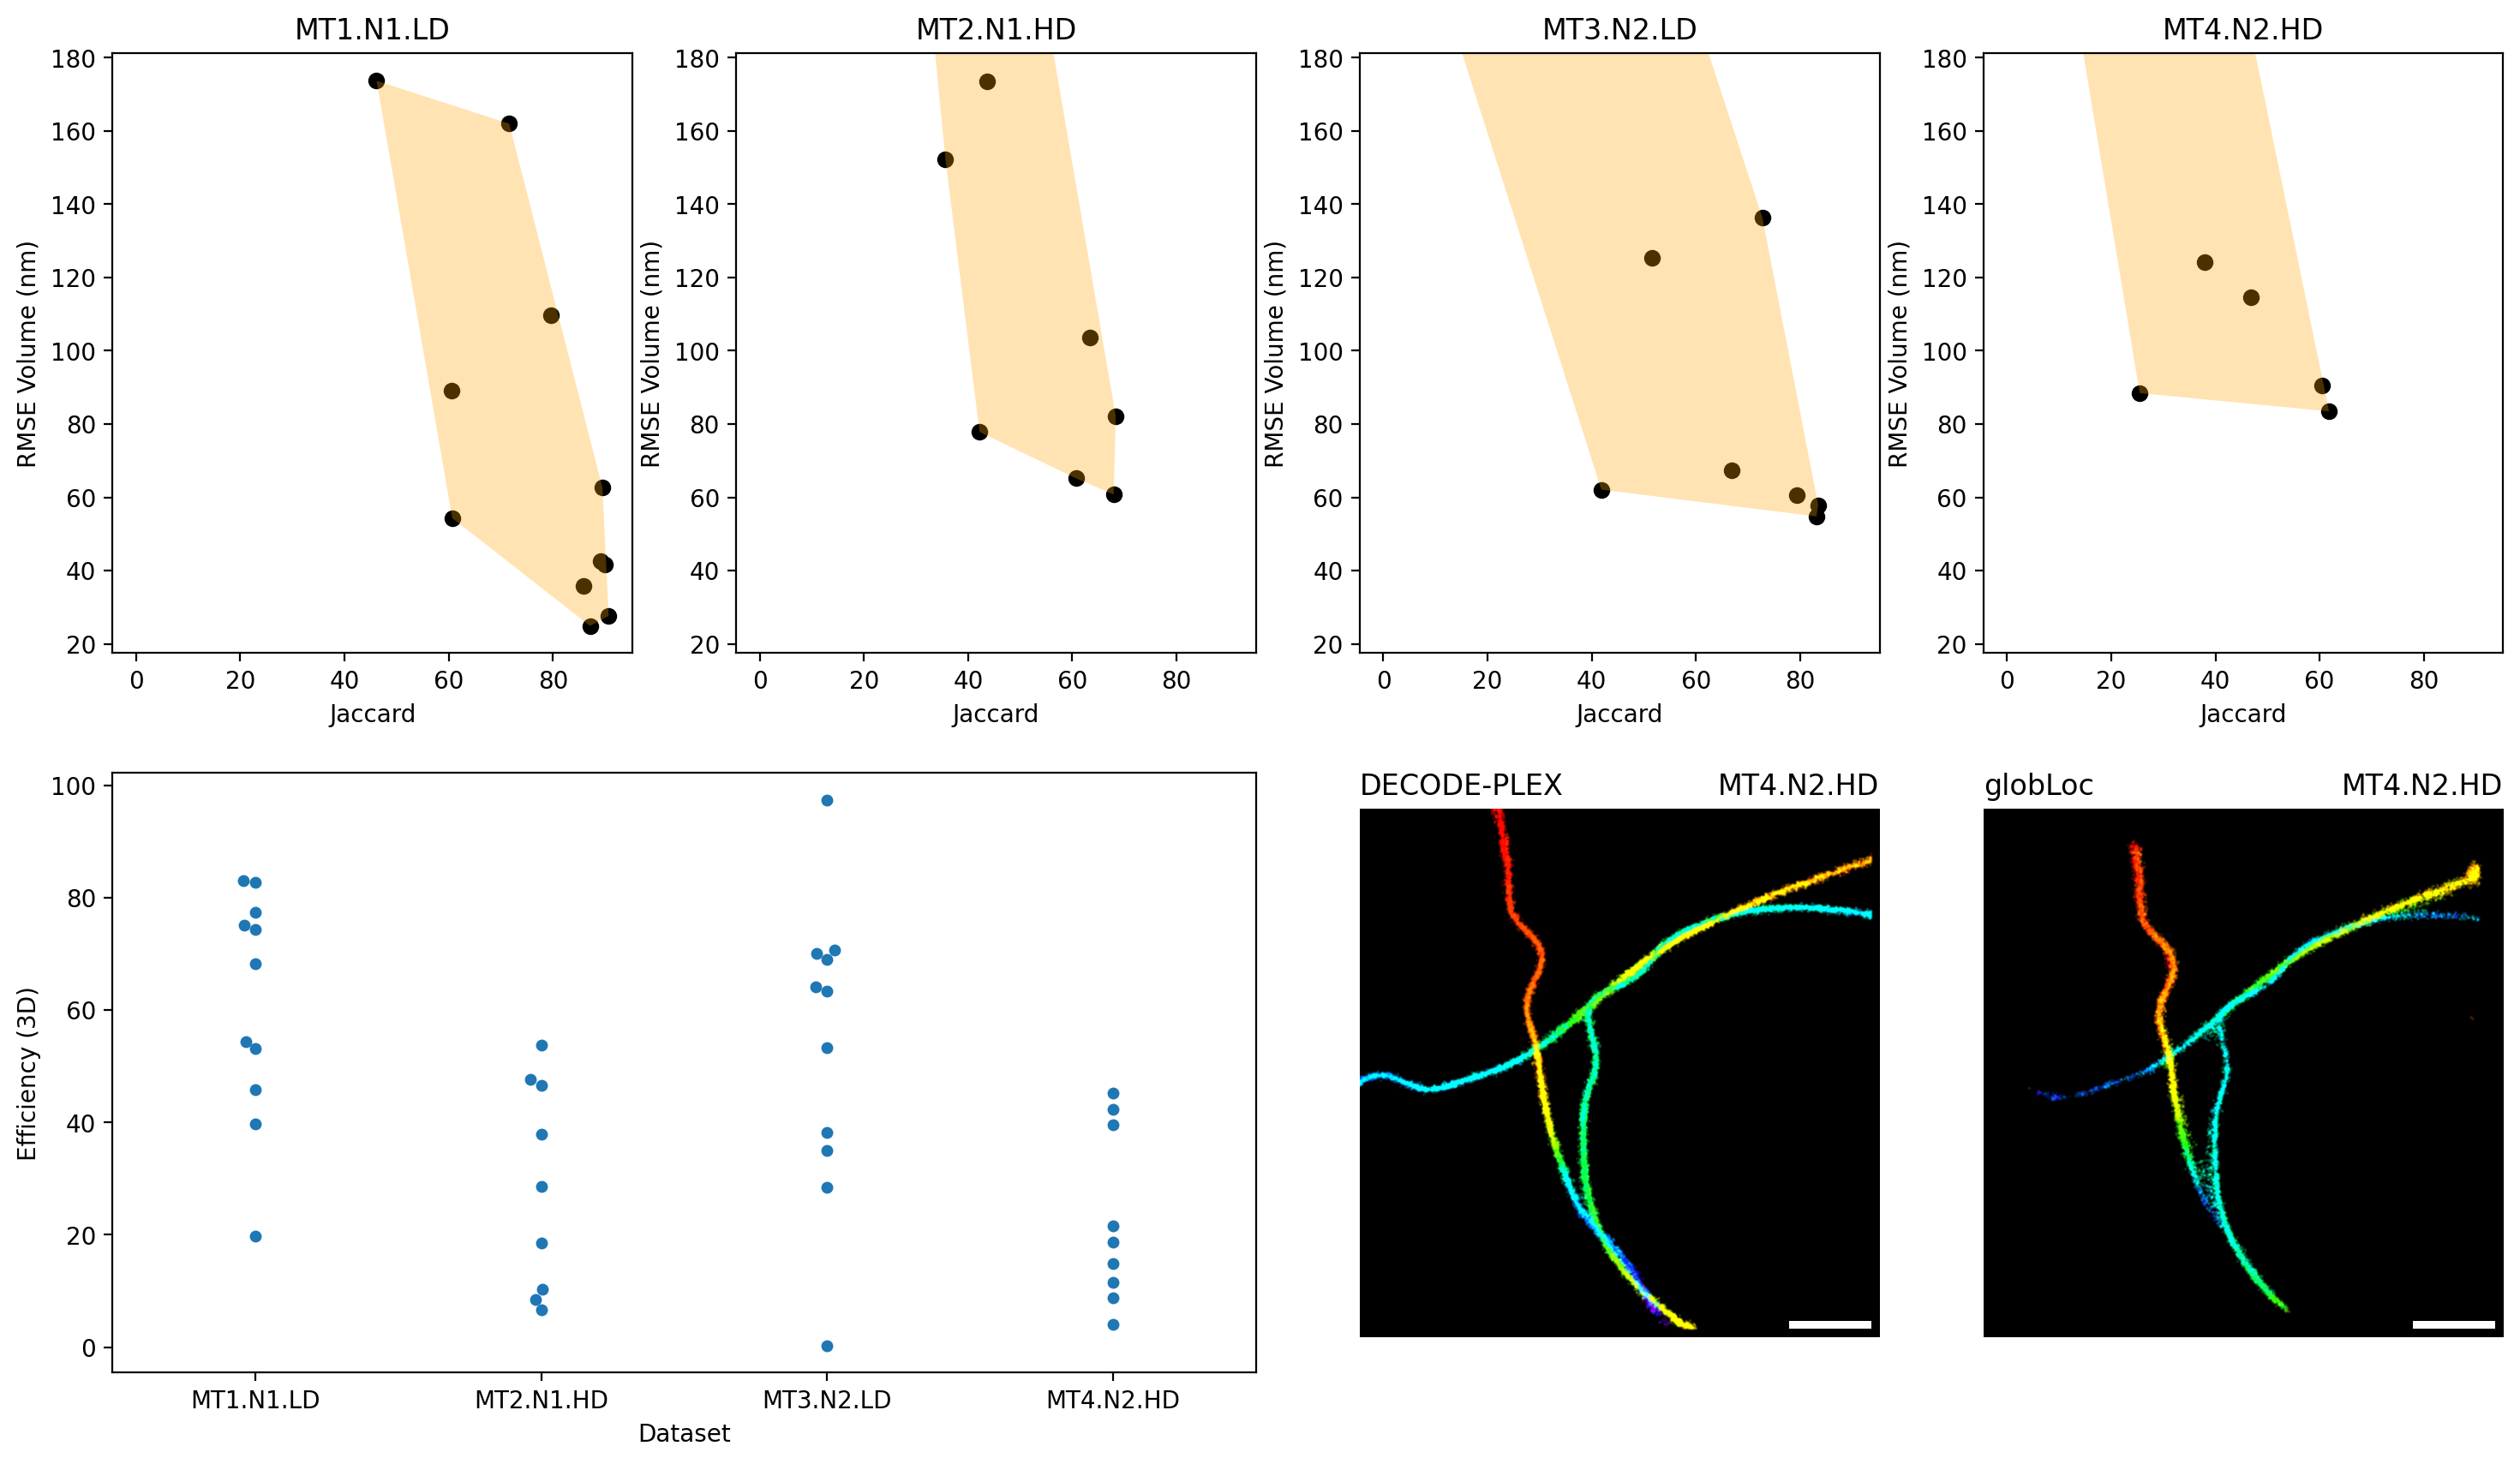

In [9]:
fig = plt.figure(figsize=(18, 10))

# Define the grid layout
gs = gridspec.GridSpec(2, 4, height_ratios=[1, 1])

ds = ['MT1.N1.LD', 'MT2.N1.HD', 'MT3.N2.LD', 'MT4.N2.HD']
m_x = "Jaccard"
m_y = "RMSE Volume (nm)"

axs = []

# top row
for i, d in enumerate(ds):
    ax = fig.add_subplot(gs[0, i])
    data = df_bp.xs(d, level="Dataset")

    ax.scatter(data[m_x], data[m_y], color="k")

    # get convex hull
    points = np.array(data[[m_x, m_y]])
    hull = scipy.spatial.ConvexHull(points)
    hull_points = points[hull.vertices, :]
    ax.fill(hull_points[:, 0], hull_points[:, 1], 'orange', alpha=0.3, edgecolor='none')

    ax.set_xlabel(m_x)
    ax.set_ylabel(m_y)

    ax.set_title(d)
    axs.append(ax)

for i in range(4):
    axs[i].sharex(axs[0])
    axs[i].sharey(axs[0])


# bottom row
metric = "Efficiency (3D)"
ax = fig.add_subplot(gs[1, :2])

data = df_bp.reset_index()
sns.swarmplot(data=data, x="Dataset", y=metric, ax=ax)
# ax.scatter(data["Dataset"], data[metric], color="k")

label_dataset = "MT4.N2.HD"
# renderings
ax = fig.add_subplot(gs[1, 2])
ax.imshow(img)
scalebar(img.shape[1] - 110, img.shape[0] - 20, 100, ax=ax)
ax.axis("off")
ax.set_title(f"DECODE-PLEX", loc="left")
ax.set_title(label_dataset, loc="right")


ax = fig.add_subplot(gs[1, 3])
ax.imshow(img_smap)
scalebar(img_smap.shape[1] - 110, img_smap.shape[0] - 20, 100, ax=ax)
ax.axis("off")
ax.set_title("globLoc", loc="left")
ax.set_title(label_dataset, loc="right")

In [38]:
em_rend.save(path_dec.with_name(f"{path_dec.stem}_rend.h5"))
em_smap.save(path_smap.with_name(f"{path_smap.stem}_rend.h5"))